# E-commerce Sales & Customer Behavior Analysis

This project analyzes a synthetic e-commerce dataset containing customer orders from Azerbaijan in 2025.

## Objectives
- Measure revenue, profit, average order value, and return rate
- Analyze monthly sales trends
- Compare product category and city performance
- Examine delivery time and customer satisfaction
- Generate practical business recommendations

> The dataset is synthetic and created for educational and portfolio purposes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("ecommerce_sales_data.csv", parse_dates=["Order_Date"])
df.head()


,Order_ID,Order_Date,Customer_ID,Age_Group,Gender,City,Category,Product,Quantity,Unit_Price_AZN,Discount_Pct,Payment_Method,Delivery_Days,Rating,Returned,Gross_Revenue_AZN,Net_Revenue_AZN,Cost_AZN,Profit_AZN
0,ORD101409,2025-01-01,C0582,18-24,Male,Baku,Books,Novel,2,29.80,0,Cash on Delivery,6,3.7,Yes,59.60,0.00,5.364,-5.36
1,ORD101996,2025-01-01,C0484,35-44,Female,Sumgayit,Sports,Dumbbell Set,3,52.01,0,Card,3,4.1,No,156.03,156.03,88.940,67.09
2,ORD102316,2025-01-01,C0652,25-34,Female,Sumgayit,Fashion,Handbag,1,84.76,0,Digital Wallet,2,4.0,No,84.76,84.76,46.620,38.14
3,ORD101482,2025-01-01,C0483,25-34,Male,Sumgayit,Fashion,T-shirt,1,129.80,0,Cash on Delivery,6,4.5,No,129.80,129.80,71.390,58.41
4,ORD102442,2025-01-01,C0346,45-54,Female,Quba,Electronics,Bluetooth Speaker,1,110.41,10,Card,2,3.8,No,110.41,99.37,79.500,19.87


## 1. Data Overview

In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))
print("\nDuplicate rows:", df.duplicated().sum())


Rows: 3000
Columns: 19

Missing values:


Order_ID          0
Order_Date        0
Customer_ID       0
Age_Group         0
Gender            0
City              0
Category          0
Product           0
Quantity          0
Unit_Price_AZN    0
dtype: int64


Duplicate rows: 0


## 2. Key Performance Indicators

In [3]:
total_orders = len(df)
total_revenue = df["Net_Revenue_AZN"].sum()
total_profit = df["Profit_AZN"].sum()
avg_order_value = total_revenue / total_orders
overall_return_rate = (df["Returned"] == "Yes").mean() * 100
avg_rating = df["Rating"].mean()

kpis = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Total Net Revenue (AZN)",
        "Total Profit (AZN)",
        "Average Order Value (AZN)",
        "Return Rate (%)",
        "Average Rating"
    ],
    "Value": [
        total_orders,
        round(total_revenue, 2),
        round(total_profit, 2),
        round(avg_order_value, 2),
        round(overall_return_rate, 2),
        round(avg_rating, 2)
    ]
})
kpis


,Metric,Value
0,Total Orders,3000.00
1,Total Net Revenue (AZN),407175.17
2,Total Profit (AZN),133513.24
3,Average Order Value (AZN),135.73
4,Return Rate (%),7.67
5,Average Rating,4.27


## 3. Monthly Revenue Trend

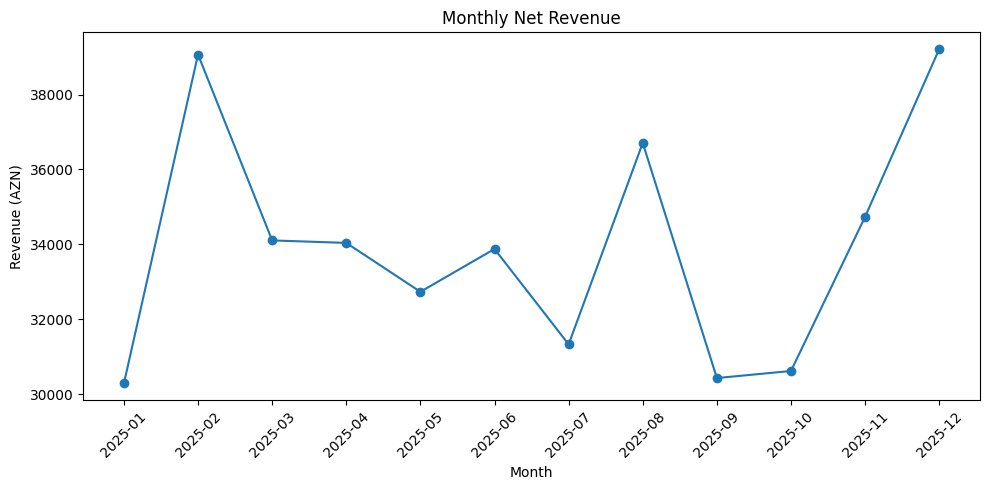

,Month,Net_Revenue_AZN
0,2025-01,30292.46
1,2025-02,39068.02
2,2025-03,34107.17
3,2025-04,34040.70
4,2025-05,32736.16
5,2025-06,33878.40
6,2025-07,31333.91
7,2025-08,36708.39
8,2025-09,30433.94
9,2025-10,30622.84


In [4]:
monthly_revenue = (
    df.assign(Month=df["Order_Date"].dt.to_period("M").astype(str))
      .groupby("Month", as_index=False)["Net_Revenue_AZN"]
      .sum()
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue["Month"], monthly_revenue["Net_Revenue_AZN"], marker="o")
plt.title("Monthly Net Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (AZN)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_revenue


## 4. Revenue and Profit by Category

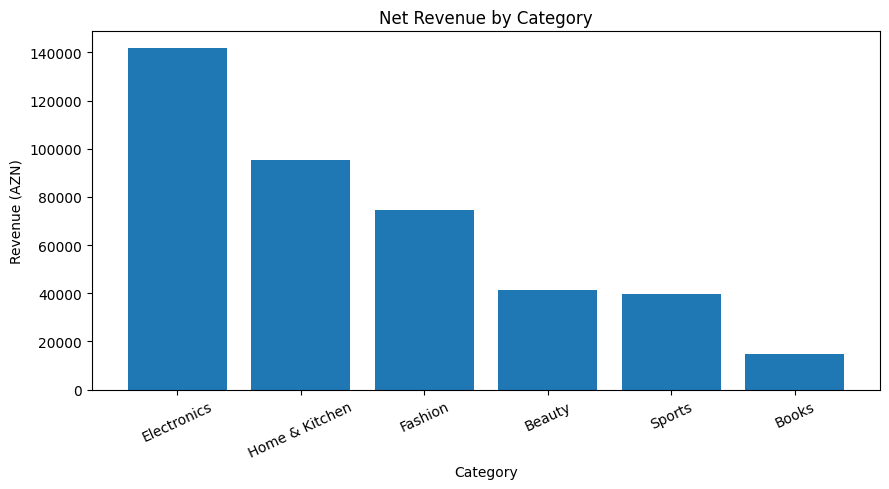

,Category,Revenue_AZN,Profit_AZN,Orders
2,Electronics,141701.43,30809.20,610
4,Home & Kitchen,95443.50,31171.77,525
3,Fashion,74630.80,29698.85,654
0,Beauty,41218.78,19797.58,499
5,Sports,39577.44,15273.99,360
1,Books,14603.22,6761.85,352


In [5]:
category_performance = (
    df.groupby("Category", as_index=False)
      .agg(
          Revenue_AZN=("Net_Revenue_AZN", "sum"),
          Profit_AZN=("Profit_AZN", "sum"),
          Orders=("Order_ID", "count")
      )
      .sort_values("Revenue_AZN", ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(category_performance["Category"], category_performance["Revenue_AZN"])
plt.title("Net Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (AZN)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

category_performance


## 5. Revenue by City

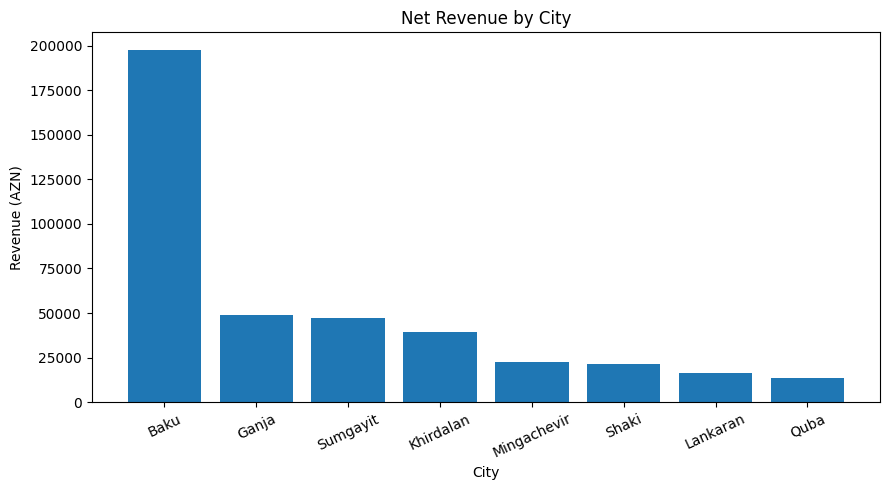

,City,Net_Revenue_AZN
0,Baku,197618.07
1,Ganja,49020.64
7,Sumgayit,47169.81
2,Khirdalan,39332.33
4,Mingachevir,22573.96
6,Shaki,21614.63
3,Lankaran,16300.18
5,Quba,13545.55


In [6]:
city_performance = (
    df.groupby("City", as_index=False)["Net_Revenue_AZN"]
      .sum()
      .sort_values("Net_Revenue_AZN", ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(city_performance["City"], city_performance["Net_Revenue_AZN"])
plt.title("Net Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue (AZN)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

city_performance


## 6. Return Rate by Category

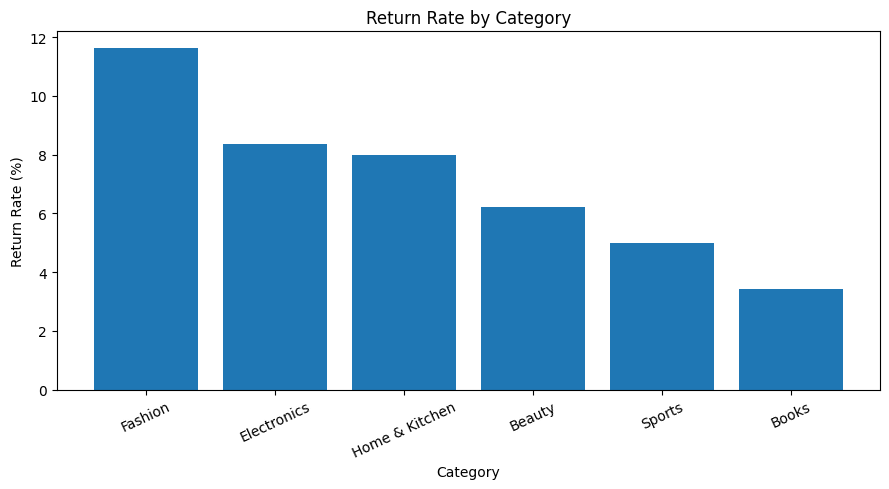

,Category,Total_Orders,Returned_Orders,Return_Rate,Return_Rate_Pct
3,Fashion,654,76,0.116208,11.620795
2,Electronics,610,51,0.083607,8.360656
4,Home & Kitchen,525,42,0.080000,8.000000
0,Beauty,499,31,0.062124,6.212425
5,Sports,360,18,0.050000,5.000000
1,Books,352,12,0.034091,3.409091


In [7]:
return_analysis = (
    df.assign(Return_Flag=(df["Returned"] == "Yes").astype(int))
      .groupby("Category", as_index=False)
      .agg(
          Total_Orders=("Order_ID", "count"),
          Returned_Orders=("Return_Flag", "sum"),
          Return_Rate=("Return_Flag", "mean")
      )
)
return_analysis["Return_Rate_Pct"] = return_analysis["Return_Rate"] * 100
return_analysis = return_analysis.sort_values("Return_Rate_Pct", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(return_analysis["Category"], return_analysis["Return_Rate_Pct"])
plt.title("Return Rate by Category")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

return_analysis


## 7. Delivery Time and Customer Ratings

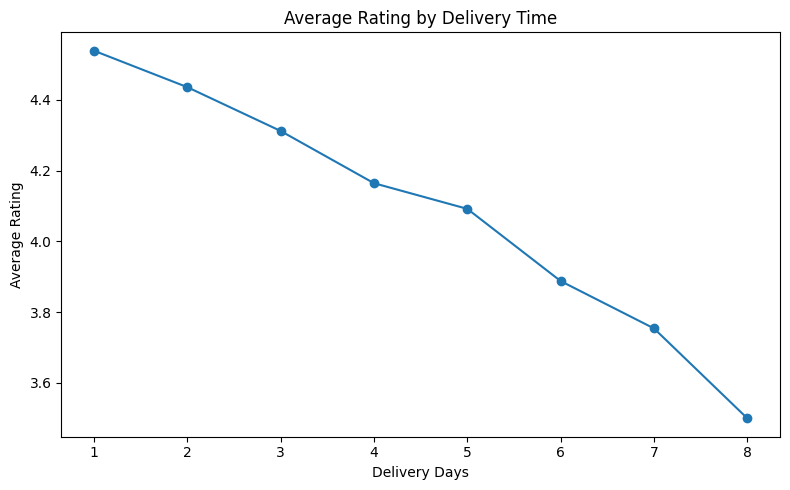

,Delivery_Days,Average_Rating,Order_Count
0,1,4.539145,304
1,2,4.436155,567
2,3,4.312310,788
3,4,4.164661,781
4,5,4.092112,393
5,6,3.888028,142
6,7,3.754167,24
7,8,3.500000,1


In [8]:
delivery_rating = (
    df.groupby("Delivery_Days", as_index=False)
      .agg(
          Average_Rating=("Rating", "mean"),
          Order_Count=("Order_ID", "count")
      )
)

plt.figure(figsize=(8, 5))
plt.plot(delivery_rating["Delivery_Days"], delivery_rating["Average_Rating"], marker="o")
plt.title("Average Rating by Delivery Time")
plt.xlabel("Delivery Days")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

delivery_rating


## 8. Top Customers

In [9]:
top_customers = (
    df.groupby("Customer_ID", as_index=False)
      .agg(
          Orders=("Order_ID", "count"),
          Revenue_AZN=("Net_Revenue_AZN", "sum")
      )
      .sort_values("Revenue_AZN", ascending=False)
      .head(10)
)

top_customers


,Customer_ID,Orders,Revenue_AZN
361,C0376,8,2934.42
720,C0750,7,2626.80
373,C0389,5,2381.29
174,C0183,4,2212.07
613,C0636,6,2192.99
418,C0435,7,2055.69
456,C0473,6,2054.00
847,C0882,8,2043.94
128,C0135,6,1882.88
589,C0611,10,1629.46


## 9. Final Insights and Recommendations

### Insights
- The highest-revenue category should receive stronger inventory and marketing support.
- High-return categories require a review of product descriptions, quality, sizing, and customer expectations.
- Longer delivery times are associated with lower customer satisfaction.
- City-level performance can guide regional campaigns and logistics planning.
- Repeat and high-value customers can be targeted with loyalty offers.

### Recommendations
1. Prioritize high-performing categories and cities.
2. Reduce delivery times for orders taking six or more days.
3. Investigate product return reasons in high-risk categories.
4. Create personalized offers for repeat customers.
5. Monitor key KPIs monthly.
